In [1]:
import sys
# !{sys.executable} -m pip install -e gym-examples

# Setup Environment

In [2]:
import gymnasium as gym
import gym_examples
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

sys.path.append("./rlearn/rlearn/")
import attacker as attacker
import defender as defender
import network as network
from ddqn2 import DQN

%load_ext autoreload
%autoreload 2

# Initialize the environment
env = gym.make('gym_examples/CERERE-v0', render_mode="human", scenario='military')
# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()
# if GPU is to be used.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

[-23, -22, -21, -20, -19, -18, -22, -21, -20, -19, -18, 0, -22, -21, -20, -19, -18, -17, -21, -20, -19, -18, -17, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Size state space 45, Size action space 24


In [3]:
Transition = namedtuple('Transition', ('state', 'action', 'next_state', 'reward'))

class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

# BATCH_SIZE is the number of transitions sampled from the replay buffer
# GAMMA is the discount factor as mentioned in the previous section
# EPS_START is the starting value of epsilon
# EPS_END is the final value of epsilon
# EPS_DECAY controls the rate of exponential decay of epsilon, higher means a slower decay
# TAU is the update rate of the target network
# LR is the learning rate of the ``AdamW`` optimizer
BATCH_SIZE = 128
GAMMA = 0.99
EPS_START = 0.9
EPS_END = 0.05
EPS_DECAY = 100  # 1000
TAU = 0.005
LR = 1e-4

# Get number of actions from gym action space
n_actions = env.action_space.n
# Get the number of state observations
state, info = env.reset()
n_observations = len(state)
# env.unwrapped._render_frame()  # plot the current state of the network

print(n_actions, n_observations)

policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000)

steps_done = 0

def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * \
        math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            # t.max(1) will return the largest column value of each row.
            # second column on max result is index of where max element was
            # found, so we pick action with the larger expected reward.
            selected_action = policy_net(state).max(1).indices.view(1,1)  # value with the highest expected reward
            return selected_action
    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)


episode_durations = []


def plot_durations(show_result=False):
    plt.figure(1)
    durations_t = torch.tensor(episode_durations, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Episode')
    # plt.ylabel('Duration')
    plt.ylabel('Reward')
    plt.plot(durations_t.numpy())
    # Take 10 episode averages and plot them too
    if len(durations_t) >= 10:
        means = durations_t.unfold(0, 10, 1).mean(1).view(-1)
        means = torch.cat((torch.zeros(9), means))
        plt.plot(means.numpy())

    plt.pause(0.001)  # pause a bit so that plots are updated
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

24 45


/home/wifi/.local/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:188: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


In [4]:
def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    # Transpose the batch (see https://stackoverflow.com/a/19343/3343043 for
    # detailed explanation). This converts batch-array of Transitions
    # to Transition of batch-arrays.
    batch = Transition(*zip(*transitions))

    # Compute a mask of non-final states and concatenate the batch elements
    # (a final state would've been the one after which simulation ended)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                          batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state
                                                if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Compute Q(s_t, a) - the model computes Q(s_t), then we select the
    # columns of actions taken. These are the actions which would've been taken
    # for each batch state according to policy_net
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # Compute V(s_{t+1}) for all next states.
    # Expected values of actions for non_final_next_states are computed based
    # on the "older" target_net; selecting their best reward with max(1).values
    # This is merged based on the mask, such that we'll have either the expected
    # state value or 0 in case the state was final.
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    # Compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Compute Huber loss
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    # In-place gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

# Train The Model

  0%|          | 0/1000 [00:00<?, ?it/s]/home/wifi/.local/lib/python3.10/site-packages/gymnasium/utils/passive_env_checker.py:188: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
100%|██████████| 1000/1000 [00:29<00:00, 33.48it/s]



Complete


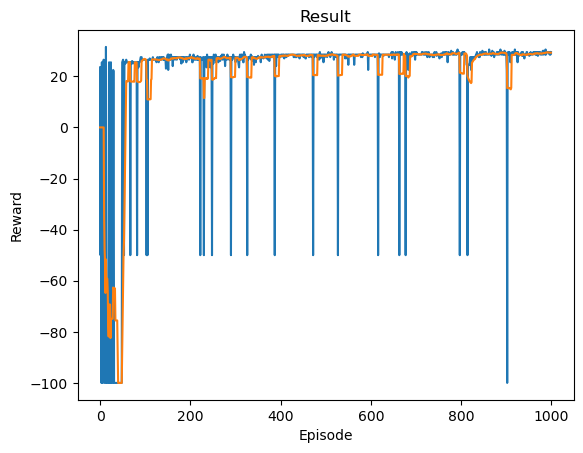

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [5]:
## Train the model
# env = gym.make('gym_examples/CERERE-v0', render_mode=None, scenario='military')

# set up matplotlib
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

plt.ion()

# if GPU is to be used
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

episode_list = []


if torch.cuda.is_available():
    num_episodes = 6000
else:
    num_episodes = 1000

for i_episode in tqdm(range(num_episodes)):
    # Initialize the environment and get its state
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    action_list = []
    no_change_of_state_counter = 0
    last_reward = None
    for t in count():
        action = select_action(state)
        action_list.append(env.unwrapped.actionSpace[action])
        observation, reward, terminated, truncated, _ = env.step(action.item())
        reward = torch.tensor([reward], device=device)
        done = terminated or truncated
        
        if last_reward == reward:
            no_change_of_state_counter += 1
            if no_change_of_state_counter >= 3: done, terminated = True, True
        else:
            no_change_of_state_counter = 0
        
        last_reward = reward

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)

        # Store the transition in memory
        memory.push(state, action, next_state, reward)

        # Move to the next state
        state = next_state

        # Perform one step of the optimization (on the policy network)
        optimize_model()

        # Soft update of the target network's weights
        # θ′ ← τ θ + (1 −τ )θ′
        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key]*TAU + target_net_state_dict[key]*(1-TAU)
        target_net.load_state_dict(target_net_state_dict)

        if done:
            # episode_durations.append(t + 1)  # append duration of an episode
            episode_durations.append(reward)  # append reward of an episode
            # plot_durations()
            break
    
    episode_list.append([reward[0].item(), action_list])

print('\nComplete')
plot_durations(show_result=True)
plt.ioff()
plt.show()

{31.5: 1, 30.5: 5, 30.0: 6, 29.5: 96, 29.0: 14, 28.5: 409, 28.0: 20, 27.5: 186, 27.0: 21, 26.5: 88, 26.0: 9, 25.5: 51, 25.0: 5, 24.5: 11, 24.0: 3, 23.5: 6, 23.0: 1, 22.5: 8, 22.0: 1, -50: 22, -100: 37}
{'tr_m_2_4': 1475, 'tr_m_2_3': 1184, 'ac_2_5': 782, 'tr_m_2_5': 721, 'ac_2_4': 367, 'tr_m_2_2': 345, 'nothing': 277, 'ac_2_2': 68, 'ac_2_3': 48, 'as_hq': 20, 'tr_m_1_5': 19, 'ac_1_2': 19, 'ac_1_4': 19, 'tr_m_1_4': 16, 'as_hqa': 15, 'tr_m_1_1': 14, 'tr_hq': 14, 'ac_1_3': 14, 'tr_m_2_1': 13, 'ac_1_5': 13, 'tr_m_1_2': 13, 'tr_m_1_3': 12, 'ac_1_1': 10, 'ac_2_1': 6}


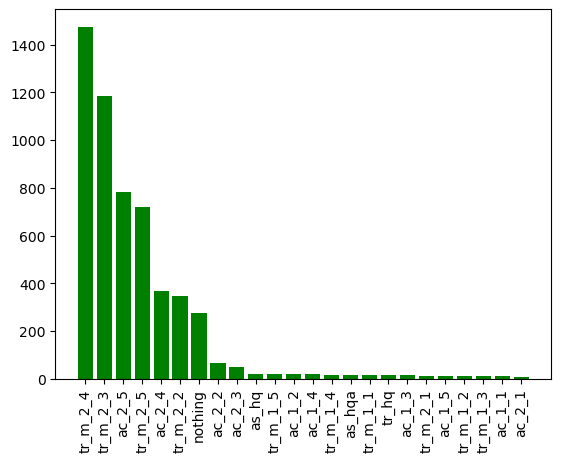

In [6]:
def count_actions(episode_list):
    rewards, actions = {}, {}
    for entry in episode_list:
        if entry[0] in rewards:
            rewards[entry[0]] += 1
        else: 
            rewards[entry[0]] = 1
        for action in entry[1]:
            if action in actions:
                actions[action] += 1
            else:
                actions[action] = 1
    rewards = dict(sorted(rewards.items(), key=lambda item: item[0], reverse=True))
    actions = dict(sorted(actions.items(), key=lambda item: item[1], reverse=True))
    return rewards, actions

rewards, actions = count_actions(episode_list)
print(rewards)
print(actions)
# episode_list
plt.bar(actions.keys(), actions.values(), color='g')
plt.xticks(rotation=90, ha="center")
plt.show()

# Test The Model

## Initial State ##
tensor([[-23., -22., -21., -20., -19., -18., -22., -21., -20., -19., -18.,   0.,
         -22., -21., -20., -19., -18., -17., -21., -20., -19., -18., -17.,   1.,
           1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
           1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.]]) {'Infected critical server': False}
Reward: 22.5, Terminated: 0, Info: {'Infected critical server': False}


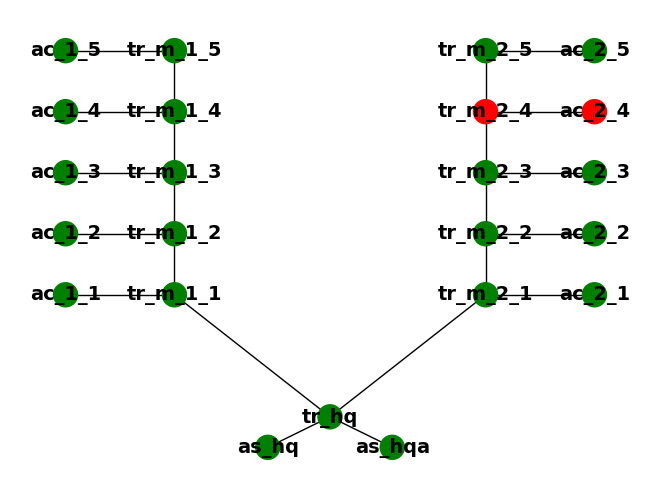

In [7]:
# Test the model
print("## Initial State ##")
state, info = env.reset()
# print(state, info)
state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
print(state, info)
reward, terminated, healthy_nodes, reachable_nodes, infected_nodes = network.get_reward_new(env.unwrapped.critserver, env.unwrapped.optserver, env.unwrapped.topology, env.unwrapped.nwstate, 0, env.unwrapped.netgraph)
print(f"Reward: {reward}, Terminated: {terminated}, Info: {info}")

# print(policy_net(state))
# max_i = policy_net(state).max(1).indices.view(1, 1)
# indexes = policy_net(state).sort(dim=1, descending=True)[1]
# print([env.actionSpace[i] for i in indexes[0].numpy()])

env.render()  # render the current network state

## Step ##
Chosen action: tensor([[8]]) -> tr_m_2_3
tensor([[-23., -22., -21., -20., -19., -18., -22., -21., -20., -19., -18.,   0.,
         -22., -21., -20., -19., -18., -17., -21., -20., -19., -18., -17.,   1.,
           1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,
           1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.,   1.]]) {'Infected critical server': False}
Reward: 28.5, Terminated: False, Info: {'Infected critical server': False}, Truncated: False


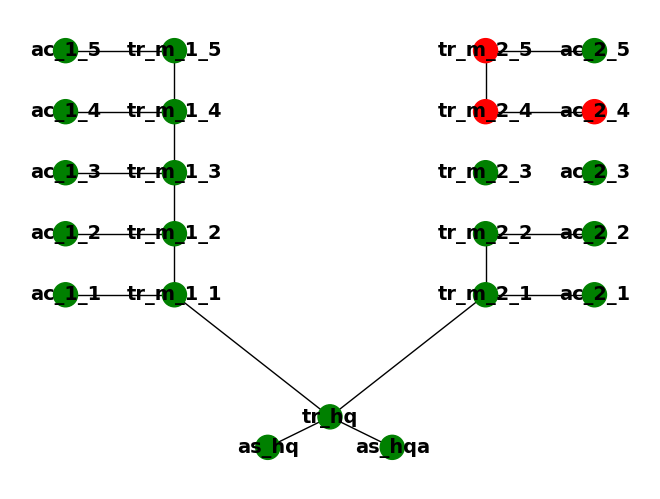

In [8]:
print("## Step ##")
action = select_action(state)
print(f"Chosen action: {action} -> {env.unwrapped.actionSpace[action]}")
observation, reward, terminated, truncated, info = env.step(action)
print(state, info)
print(f"Reward: {reward}, Terminated: {terminated}, Info: {info}, Truncated: {truncated}")
env.render()

# Store And Load The Model

In [9]:
# test to save the model
torch.save(policy_net.state_dict(), "model_test.pt")

45 24
{25.0: 1, 24.0: 1, 23.5: 1, -50: 7}
{'tr_m_2_3': 1808, 'tr_m_1_3': 9, 'tr_m_2_1': 7, 'as_hq': 7, 'ac_1_1': 7, 'nothing': 7, 'tr_m_1_2': 6, 'tr_m_2_5': 6, 'ac_2_4': 5, 'tr_m_1_4': 5, 'ac_2_5': 4, 'ac_1_4': 4, 'ac_1_2': 4, 'tr_m_2_2': 3, 'tr_m_1_5': 3, 'ac_1_5': 3, 'tr_m_1_1': 3, 'as_hqa': 3, 'ac_2_2': 2, 'tr_hq': 2, 'ac_2_1': 2, 'ac_2_3': 2, 'ac_1_3': 2, 'tr_m_2_4': 1}


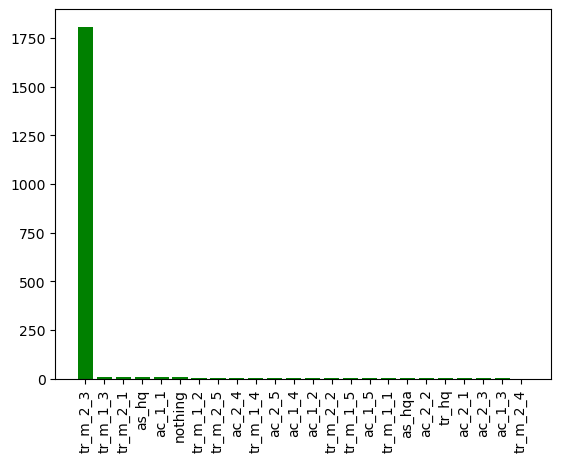

In [10]:
# Load the trained model and test it for a certain nuber of rounds
print(n_observations, n_actions)
current_model = DQN(45,24)
current_model.load_state_dict(torch.load("model_test.pt"))
current_model.eval()

episode_list = []
max_episodes = 10
for i in range(max_episodes):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    action_list = []
    for t in count():
        action = select_action(state)
        action_list.append(env.unwrapped.actionSpace[action])
        observation, reward, terminated, truncated, _ = env.step(action.item())
        reward = torch.tensor([reward], device=device)
        done = terminated or truncated
        if done:
            # episode_durations.append(t + 1)  # append duration of an episode
            episode_durations.append(reward)  # append reward of an episode
            # plot_durations()
            break    
    episode_list.append([reward[0].item(), action_list])

rewards, actions = count_actions(episode_list)
print(rewards)
print(actions)
# episode_list
plt.bar(actions.keys(), actions.values(), color='g')
plt.xticks(rotation=90, ha="center")
plt.show()